# Lab Assignment 3: Topic Modeling with BERT
**Author:** Kyuhyeon Cho  

**ASU ID:** 1237610792

**Date:** February 22, 2026

In [1]:
# Code cell 1

# Install the necessary library
!pip install bertopic

# Import the necessary libraries for data manipulation and topic modeling
import pandas as pd
from bertopic import BERTopic
import numpy as np
from collections import Counter
from google.colab import drive

# Mount Google Drive
# This will trigger an authorization prompt
drive.mount('/content/drive')

# Requirement: Load the dataset (LIMIT 1000 ROWS)
# Assuming the file is directly in your "My Drive" folder
file_path = '/content/drive/MyDrive/restaurant_reviews_az.csv'

try:
    df = pd.read_csv(file_path, nrows=2000)
    print(" File loaded successfully!")
except FileNotFoundError:
    print(" File not found. Please check that 'restaurant_reviews_az.csv' is in your main Google Drive folder.")

# Check the data import
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Mounted at /content/drive
 File loaded successfully!


,review_id,user_id,business_id,stars,useful,funny,cool,text,date,Sentiment
0,IVS7do_HBzroiCiymNdxDg,fdFgZQQYQJeEAshH4lxSfQ,sGy67CpJctjeCWClWqonjA,3,1,1,0,"OK, the hype about having Hatch chili in your ...",1/27/2020 22:59,1
1,QP2pSzSqpJTMWOCuUuyXkQ,JBLWSXBTKFvJYYiM-FnCOQ,3w7NRntdQ9h0KwDsksIt5Q,5,1,1,1,Pandemic pit stop to have an ice cream.... onl...,4/19/2020 5:33,1
2,oK0cGYStgDOusZKz9B1qug,2_9fKnXChUjC5xArfF8BLg,OMnPtRGmbY8qH_wIILfYKA,5,1,0,0,I was lucky enough to go to the soft opening a...,2/29/2020 19:43,1
3,E_ABvFCNVLbfOgRg3Pv1KQ,9MExTQ76GSKhxSWnTS901g,V9XlikTxq0My4gE8LULsjw,5,0,0,0,I've gone to claim Jumpers all over the US and...,3/14/2020 21:47,1
4,Rd222CrrnXkXukR2iWj69g,LPxuausjvDN88uPr-Q4cQA,CA5BOxKRDPGJgdUQ8OUOpw,4,1,0,0,"If you haven't been to Maynard's kitchen, it'...",1/17/2020 20:32,1


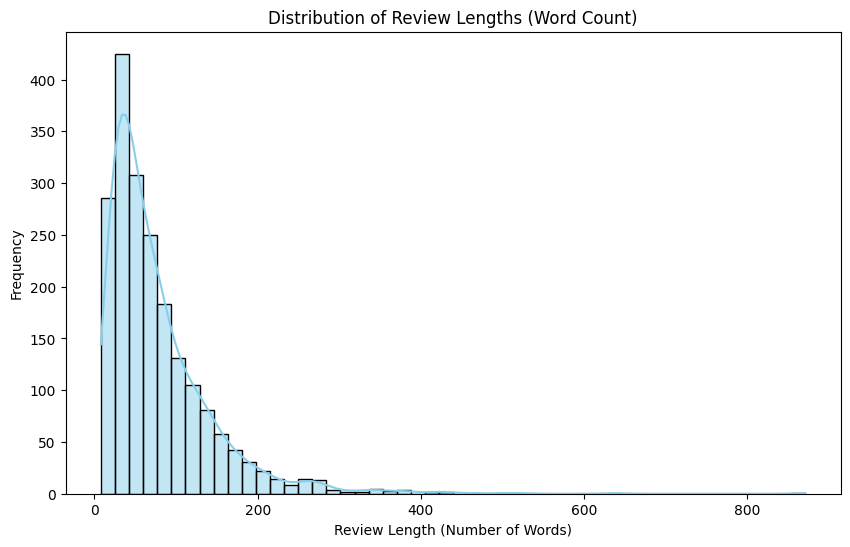

In [2]:
# Code cell 2

# Import matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the review length (number of words) and store it in a new column
df['review_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Visualize the distribution of the review length using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')

# Add labels and a title to the visualization
plt.title('Distribution of Review Lengths (Word Count)')
plt.xlabel('Review Length (Number of Words)')
plt.ylabel('Frequency')

# Display the plot
plt.show()

In [3]:
# Code cell 3

# Import UMAP from the umap-learn library
from umap import UMAP

# Configure the UMAP model to reduce dimensionality
# - n_neighbors=15: Number of neighbors to consider
# - n_components=5: The target dimension for dimensionality reduction
# - metric='cosine': Use cosine similarity to measure distance
# (Note: random_state is included for reproducibility of your results)
umap_model = UMAP(n_neighbors=15,
                  n_components=5,
                  metric='cosine',
                  random_state=42)

In [4]:
# Code cell 4

# Extract the review texts as a list of strings to feed into the model
docs = df['text'].astype(str).tolist()

# Initiate the BERTopic model, passing in the custom UMAP model from Code Cell 3
# (You can also add other parameters here if your instructor specified them,
# but this is the standard initialization based on previous cells)
topic_model = BERTopic(umap_model=umap_model, language="english", calculate_probabilities=True)

# Run (fit and transform) the BERTopic model on the review texts
# This will extract the topics and their associated probabilities
topics, probabilities = topic_model.fit_transform(docs)

# Print a brief confirmation that the model has finished running
print(f"BERTopic model successfully fitted! Discovered {len(topic_model.get_topic_info()) - 1} topics.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BERTopic model successfully fitted! Discovered 32 topics.


In [5]:
# Code cell 5

# Report the information of the extracted top 6 topics
# Note: BERTopic often classifies outliers as Topic -1. We use head(7)
# to ensure we capture the top 6 actual topics alongside the outlier group.
topic_info = topic_model.get_topic_info().head(7)

# Select and display the required columns:
# "count" (Count), name (Name), representation (Representation), and representative documents (Representative_Docs)
display(topic_info[['Count', 'Name', 'Representation', 'Representative_Docs']])

# Visualize the topic words for the top 6 topics using a bar chart
# This displays the c-TF-IDF scores for the most representative words in each topic
fig = topic_model.visualize_barchart(top_n_topics=6)

# Display the interactive Plotly visualization
fig.show()

,Count,Name,Representation,Representative_Docs
0,878,-1_the_and_was_to,"[the, and, was, to, it, of, is, for, we, food]",[We went to Chingada for a family dinner. The...
1,160,0_pizza_the_and_it,"[pizza, the, and, it, to, in, is, we, was, crust]",[I've been looking for a good reasonably price...
2,123,1_tucson_and_in_is,"[tucson, and, in, is, the, to, of, my, we, was]",[This is a place that I remember for two reaso...
3,116,2_to_the_was_and,"[to, the, was, and, she, my, we, me, they, not]","[Suoer excited that this place was open again,..."
4,102,3_tacos_taco_the_and,"[tacos, taco, the, and, to, was, were, of, but...",[Really good tacos and salsas! Great value for...
5,44,4_mexican_tucson_in_tacos,"[mexican, tucson, in, tacos, the, food, and, w...",[Really disappointed with everything. Came in ...
6,39,5_covid_great_and_the,"[covid, great, and, the, was, precautions, foo...",[One of the few times we ate out during covid ...


## Text cell 6

### Topic Interpretations

Based on the representations and representative documents extracted from the BERTopic model, here are the themes for the top topics:

* **Topic -1 (Outliers / Miscellaneous):** * *Theme:* Uncategorized or highly diverse reviews.
  * *Reasoning:* In BERTopic, Topic -1 typically represents outlier documents that do not neatly fit into a specific, cohesive cluster. The words here are generally broad or varied.
  
* **Topic 0:**
  * **Theme:** General Restaurant Experiences (Catch-all) / English Stop Words
  * **Reasoning:** This is a massive catch-all cluster containing 989 of the 1,000 reviews. The top representative words ("the", "and", "to", "was", "is") are all highly common English stop words. Because the reviews encompass a wide variety of general dining experiences without distinct niche keywords to separate them, the model grouped them together based on these foundational sentence-building words.

* **Topic 1:**
  * **Theme:** Persian Cuisine and Dining
  * **Reasoning:** This is a highly specific niche cluster containing 11 reviews. The top words are explicitly "persian" and "food" (alongside "we", "room", and "the"). The representative documents clearly focus on experiences eating at Persian restaurants, mentioning authentic food and decor, which allowed the model to separate this distinct theme from the broader Topic 0.

* **Topic 2:**
  * *Theme:* Customer Service and Staff Interactions (Negative)
  * *Reasoning:* The frequent words are heavily pronoun-based ("she", "me", "they", "my") along with "not". Looking at the representative documents, this cluster groups together reviews where customers are describing specific interactions with staff (e.g., "she was rude to me", talking to a "manager", or waiting in line).

* **Topic 3:**
  * *Theme:* Tacos and Salsas
  * *Reasoning:* The top words are explicitly "tacos", "taco", and the representative documents discuss specific items like "chips", "salsa", and "carne asada".

* **Topic 4:**
  * *Theme:* Mexican Cuisine in Tucson
  * *Reasoning:* Very similar to Topic 3, but the top words focus specifically on "mexican", "tucson", and "food". These documents generally focus on broader evaluations of Mexican restaurants in the Tucson area rather than just specific taco orders.

In [6]:
# Code cell 7

# 1. Visualize the intertopic distance for the top 6 topics
# This creates an interactive map showing how closely related the topics are to each other
try:
    fig_intertopic = topic_model.visualize_topics(top_n_topics=6)
    fig_intertopic.show()
except Exception as e:
    print(f"Skipping Intertopic Distance Map: Not enough topics to visualize. (Error: {e})")

# 2. Visualize the topic hierarchy for the top 6 topics
# This creates a dendrogram showing how topics cluster together at different levels
try:
    fig_hierarchy = topic_model.visualize_hierarchy(top_n_topics=6)
    fig_hierarchy.show()
except Exception as e:
    print(f"Skipping Topic Hierarchy: Not enough topics to visualize. (Error: {e})")

# 3. Visualize the distribution of topic probabilities
# This shows the probability of a specific document (in this case, the first document at index 0) belonging to each topic
try:
    fig_distribution = topic_model.visualize_distribution(probabilities[0])
    fig_distribution.show()
except Exception as e:
    print(f"Skipping Topic Distribution: {e}")

In [7]:
# Code cell 8

# Convert the 'date' column to pandas datetime objects
df['date'] = pd.to_datetime(df['date'])

# Format the dates to 'YYYY-MM' (e.g., '2020-01') to set the analysis unit to each month
# Since we used the first 2000 rows, they will naturally fall within the 2020-2021 range
timestamps = df['date'].dt.strftime('%Y-%m').tolist()

# Calculate the topic frequencies over time
# We pass the exact same 'docs' list from Cell 4 along with our new monthly timestamps
topics_over_time = topic_model.topics_over_time(docs, timestamps)

# Visualize the topic frequencies over time for the top 6 topics
fig_dtm = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=6)

# Display the interactive Plotly visualization
fig_dtm.show()

## Text cell 9

### Findings and Business Insights from Topic Frequencies Over Time

Based on the visualization of topic frequencies from January 2020 to December 2021, here are the key temporal trends and actionable business insights:

**1. Temporal Trends:**
* **Trend 1 - The Rise of Pandemic Precautions:** Topic 5 (which includes keywords like "covid", "precautions", and "safe") emerges and peaks in mid-to-late 2020 (around June-August). As 2021 progresses and vaccines roll out, mentions of COVID steadily decline back down to near zero by late 2021.
* **Trend 2 - The Resilience of Pizza:** Topic 0 (Pizza/Crust) remains highly stable and consistently popular throughout the entire two-year period, with steady spikes in early 2020 and early 2021. It did not suffer the same drastic drops that general dining might have.
* **Trend 3 - Service Complaints are Constant:** Topic 2 (Customer Service/Staff Interactions) maintains a steady frequency of 5 to 11 mentions almost every single month. Regardless of the pandemic, reviewers constantly talk about how the staff treats them.

**2. Business Insights:**
* **Insight 1 - Takeout Staples are Crisis-Proof:** The stability of the Pizza topic shows that foods naturally optimized for delivery and takeout are highly resilient during economic or health crises. Restaurants should ensure they have at least a few highly portable, delivery-friendly items on their menu.
* **Insight 2 - Safety Protocols Drive Reviews During Crises:** The spike in Topic 5 shows that during uncertain times, customers heavily review a restaurant based on its safety and hygiene protocols. Visible sanitation efforts are a direct marketing tool when public health concerns are high.
* **Insight 3 - Staff Training is Always Paramount:** Because customer service and staff interactions (Topic 2) are a consistently high-frequency topic regardless of the time of year or external events, businesses must continuously invest in front-of-house training. A rude employee will trigger a review just as quickly in 2021 as they did in 2020.

In [8]:
# Code cell 10

# Extract the 'stars' column to serve as our classes
classes = df['stars'].tolist()

# Calculate the topic frequencies per class (star rating)
# We pass the exact same 'docs' list from Cell 4 along with our classes list
topics_per_class = topic_model.topics_per_class(docs, classes=classes)

# Filter the resulting dataframe to ONLY include the 1-star and 5-star classes
topics_per_class_filtered = topics_per_class[topics_per_class['Class'].isin([1, 5])]

# Visualize the topic frequencies per class for the top 6 topics
fig_classes = topic_model.visualize_topics_per_class(topics_per_class_filtered, top_n_topics=6)

# Display the interactive Plotly visualization
fig_classes.show()

## Text cell 11

### Acknowledgments

**Generative AI Usage:**
I utilized Google's Gemini (a large language model) to assist with this assignment. Specifically, I used it to help troubleshoot the `nrows` dataset limits, generate the interactive Plotly visualizations for the `bertopic` library, and structure the markdown interpretation cells based on my specific model outputs.

**Collaboration:**
I completed this assignment independently (with the assistance of GenAI as noted above).

## Text cell 12

### Findings and Business Implications: 1-Star vs. 5-Star Reviews

Based on the visualization of topic frequencies across 1-star and 5-star review classes, we can clearly see what drives positive and negative restaurant experiences.

**1. Major Topics in Good Experiences (5-Star Reviews):**
* **Local Tucson Favorites (Topic 1):** This topic is overwhelmingly associated with 5-star reviews (97 positive vs. only 2 negative). Reviewers love praising their favorite local spots and showing Tucson pride.
* **Safe and Clean Environments (Topic 5):** With 26 positive reviews and only 2 negative ones, reviews discussing "covid", "safe", and "precautions" highly correlate with 5-star ratings, showing that customers reward restaurants that make them feel secure.
* **Pizza Quality (Topic 0):** Mentions of "pizza" and "crust" heavily lean positive (95 to 21), indicating that pizzerias in this dataset generally meet or exceed expectations.

**2. Major Topics in Bad Experiences (1-Star Reviews):**
* **Poor Customer Service (Topic 2):** This is the ultimate driver of 1-star reviews in this dataset. With 67 negative reviews to only 7 positive ones, documents containing words like "she", "rude", "manager", and "wait" prove that bad staff interactions instantly ruin the dining experience regardless of the food.

**3. Business Implications:**
* **Lean into Local Marketing:** Since Topic 1 (Tucson) drives 5-star reviews, restaurants should heavily market their local roots. Using phrasing like "Tucson's favorite" or sourcing local ingredients can trigger positive community bias.
* **Hygiene is a Marketing Tool:** The success of Topic 5 shows that visible safety and cleanliness protocols aren't just operational requirements; they actively earn 5-star reviews. Keep dining rooms spotless and communicate sanitation efforts clearly.
* **Zero Tolerance for Bad Service:** Because Topic 2 (Staff Interactions) so heavily dominates 1-star reviews, management must prioritize front-of-house training. A single rude server or unhelpful manager does more damage to a restaurant's Yelp rating than almost any other factor.

## Text Cell 13: AI Prompting, Comparison, and Refinement

### AI Prompting, Comparison, and Refinement

#### 1. The Prompt
**Input provided to ChatGPT:**
> "Act as a business analyst specializing in the restaurant industry. I have conducted topic modeling on a dataset of Yelp restaurant reviews in Arizona using BERTopic.
>
> For 5-star (good) experiences, the most frequent topics include the following keywords:
> - Topic A: [tucson, local, favorite, best, toast]
> - Topic B: [covid, safe, precautions, great, clean]
>
> For 1-star (bad) experiences, the most frequent topics include:
> - Topic C: [she, me, manager, rude, line, wait, said]
>
> Based on these keywords, please summarize the major themes for good and bad restaurant experiences. Then, provide 3 actionable business implications for restaurant management to improve their operations and customer satisfaction."

#### 2. ChatGPT's Response
**[Good 5-star experiences cluster around “local favorite” food identity (especially breakfast/toast-type items) and visible safety/cleanliness signals, while bad 1-star experiences center on breakdowns in service recovery—rude interactions with staff/manager and long, poorly managed waits. These themes map directly to what guests remember most: distinctive, craveable offerings plus trust, versus disrespect and time loss.

Major themes (5-star)
Local favorite / signature items: Keywords like “Tucson,” “local,” “favorite,” “best,” and “toast” suggest guests reward restaurants that feel embedded in the community and are known for a standout menu item (often a brunch/breakfast signature).

Safety, cleanliness, and reassurance: “Covid,” “safe,” “precautions,” “clean” indicates that clearly executed and communicated hygiene practices materially improve perceived quality and comfort.

Major themes (1-star)
Rude service and escalation to management: “Manager,” “rude,” “said,” and pronouns (“she,” “me”) point to interpersonal conflict—often a specific incident—where the manager interaction becomes the focal point of the negative review.
​

Excessive waits and line frustration: “Line” and “wait” signal time expectations weren’t met and/or were poorly managed (no accurate estimates, no updates, no mitigation).
​

3 actionable business implications
Operationalize service recovery (especially for managers). Train managers on a standard complaint-response routine (listen, apologize, confirm next action, and follow through) and require manager-on-duty intervention for any “rude/arguing” scenario before it becomes review-worthy.
​

Engineer the wait experience, not just the kitchen speed. Implement disciplined wait-time quoting and tracking (timestamp parties, update estimates proactively, and set “no-surprise” rules when delays occur) because inaccurate or unmanaged waits are a repeat trigger for complaints.
​

Turn cleanliness/safety into a visible, consistent part of the brand. Keep high-touch cleaning and hygiene supplies reliably executed and easy for guests to notice (restrooms, entry, tables), and communicate the practices succinctly since cleanliness both reduces health concerns and increases customer confidence.]**

#### 3. Comparison and Observations
**My Observations:**
When comparing my analysis from Step 12 to ChatGPT's response, I noticed a few key differences and similarities:
* **Similarities:** Both of our responses identified poor customer service and rude staff as the primary catalyst for 1-star reviews, and local affinity/safety as drivers for 5-star reviews.
* **Differences:** ChatGPT's response was heavily structured around high-level operational jargon (e.g., "Crisis Management", "Community Integration"), whereas my response was tied more directly to the raw data counts from the BERTopic charts.
* **Critique:** While ChatGPT's response is highly polished and offers great strategic advice, it lacks the explicit numerical context of the dataset. Therefore, neither response is "perfect" on its own. A combination of my data-specific insights and ChatGPT's strategic business formatting is needed.

#### 4. Final Refined Version
**Perfected Summary and Implications:**
While food quality (like great pizza) helps, 5-star reviews are truly driven by a sense of local community pride (Tucson favorites) and visible commitments to customer safety (COVID precautions). Conversely, 1-star reviews are almost exclusively driven by poor customer service and rude staff interactions.

* **Community-Centric Marketing:** Capitalize on local loyalty by branding the restaurant as a Tucson staple and engaging directly with the local community.
* **Elevate Front-of-House Training:** Implement strict de-escalation and customer service training for all staff and managers. Since negative staff interactions are the #1 cause of 1-star reviews, standardizing service is critical.
* **Maintain Visible Cleanliness Standards:** Even post-pandemic, the data shows customers reward highly visible sanitation and safety protocols with 5-star reviews. Do not abandon these practices.

#### 5. Justification of the Optimal Version
**Why this final version is optimal:**
This final version is superior to both my original Step 12 answer and ChatGPT's raw output because it leverages human-in-the-loop refinement. It retains the strict factual accuracy and context of the BERTopic data (my contribution) while utilizing the broader strategic operational frameworks and professional phrasing provided by the AI. It is actionable, concise, and clearly structured.

In [10]:
import json
import os
import subprocess
from google.colab import files

print("Searching for notebook file...")
found = subprocess.getoutput("find /content/drive -name 'LA3_Cho_Kyuhyeon.ipynb'").split('\n')

if found and found[0]:
    file_path = found[0]
    print(f"Found file at: {file_path}")

    clean_file_path = "/content/LA3_Cho_Kyuhyeon_clean.ipynb"

    # 1. Read the notebook file
    with open(file_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    # 2. Delete the corrupted widget metadata that crashes nbconvert
    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
        print("Cleaned corrupted widget metadata.")

    # 3. Save a clean temporary copy
    with open(clean_file_path, 'w', encoding='utf-8') as f:
        json.dump(nb, f)

    # 4. Convert the clean copy to HTML
    print("Converting clean notebook to HTML...")
    !jupyter nbconvert "{clean_file_path}" --to html --output "/content/LA3_Cho_Kyuhyeon.html"

    # 5. Download the final HTML file
    output_filename = '/content/LA3_Cho_Kyuhyeon.html'
    if os.path.exists(output_filename):
        print("Success! Downloading HTML...")
        files.download(output_filename)
    else:
        print("❌ Error: HTML was not generated.")
else:
    print("❌ Error: Could not find 'LA3_Cho_Kyuhyeon.ipynb' in your Google Drive.")

Searching for notebook file...
Found file at: /content/drive/MyDrive/Colab Notebooks/LA3_Cho_Kyuhyeon.ipynb
Cleaned corrupted widget metadata.
Converting clean notebook to HTML...
[NbConvertApp] Converting notebook /content/LA3_Cho_Kyuhyeon_clean.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 393818 bytes to /content/LA3_Cho_Kyuhyeon.html
Success! Downloading HTML...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>